In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis
import os

os.makedirs("../outputs", exist_ok=True)

df = pd.read_csv("../data/predictive_maintenance.csv")

sensor_cols = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 3 rows:")
df.head(3)

Shape: (10000, 14)

Columns: ['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']

First 3 rows:


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0


In [2]:
print("=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Data Types ===")
print(df.dtypes)

print("\n=== Basic Stats ===")
df[sensor_cols].describe().round(3)

=== Missing Values ===
UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

=== Data Types ===
UDI                          int64
Product ID                  object
Type                        object
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object

=== Basic Stats ===


,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
count,10000.000,10000.000,10000.000,10000.000,10000.000
mean,300.005,310.006,1538.776,39.987,107.951
std,2.000,1.484,179.284,9.969,63.654
min,295.300,305.700,1168.000,3.800,0.000
25%,298.300,308.800,1423.000,33.200,53.000
50%,300.100,310.100,1503.000,40.100,108.000
75%,301.500,311.100,1612.000,46.800,162.000
max,304.500,313.800,2886.000,76.600,253.000


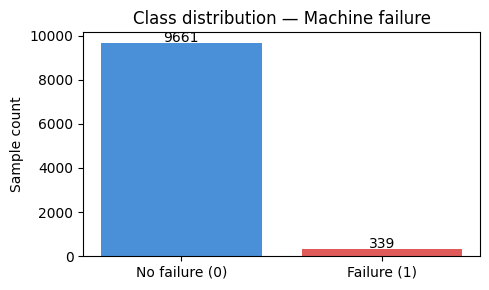

Imbalance ratio: 28.5:1


In [3]:
fig, ax = plt.subplots(figsize=(5, 3))
counts = df["Machine failure"].value_counts()

ax.bar(["No failure (0)", "Failure (1)"],
       counts.values,
       color=["#4A90D9", "#E05A5A"])

ax.set_title("Class distribution — Machine failure")
ax.set_ylabel("Sample count")

for i, v in enumerate(counts.values):
    ax.text(i, v + 30, str(v), ha="center", fontsize=10)

plt.tight_layout()
plt.savefig("../outputs/class_distribution.png", dpi=150)
plt.show()

print(f"Imbalance ratio: {counts[0]/counts[1]:.1f}:1")

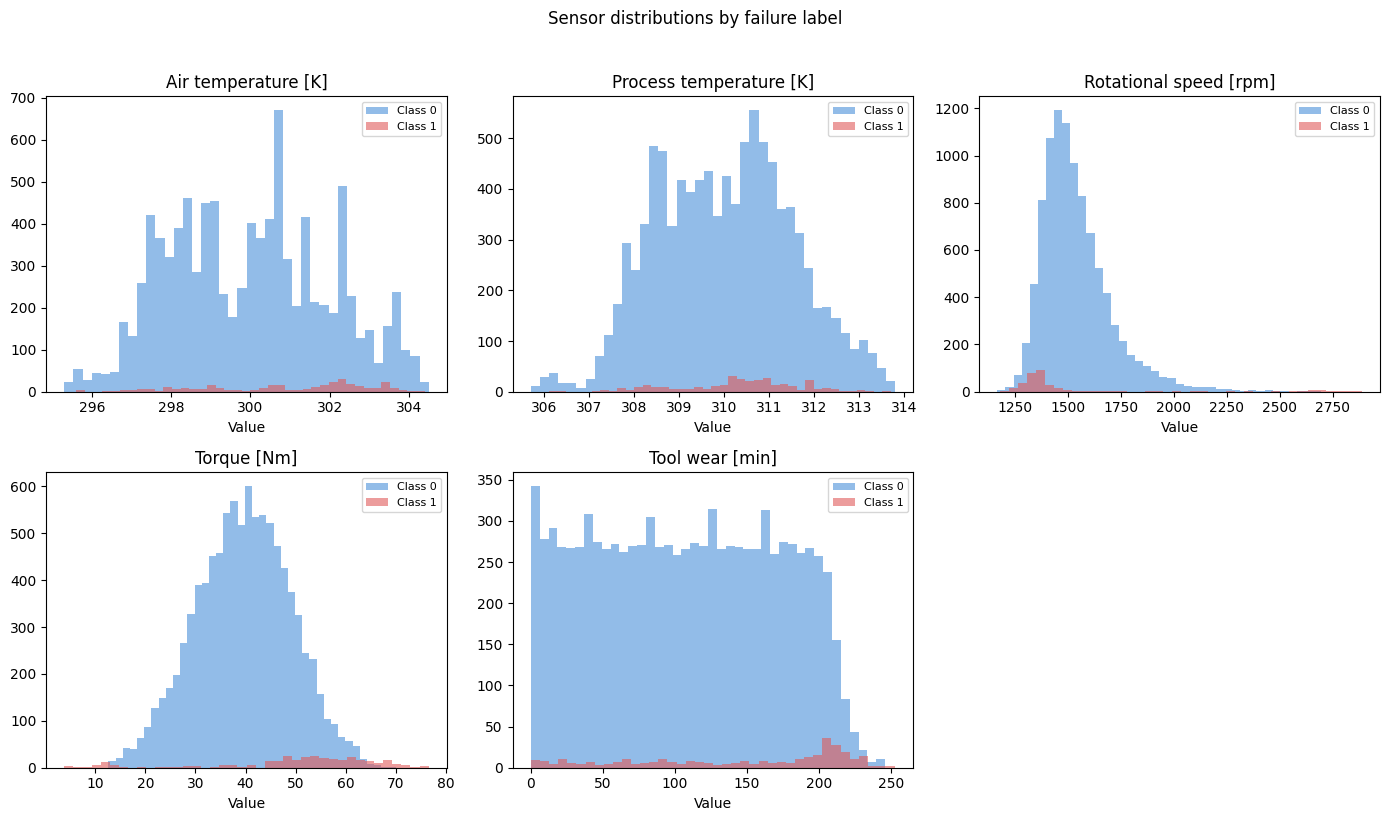

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(sensor_cols):
    for label, color in [(0, "#4A90D9"), (1, "#E05A5A")]:
        subset = df[df["Machine failure"] == label][col]
        axes[i].hist(subset, bins=40, alpha=0.6,
                     label=f"Class {label}", color=color)
    axes[i].set_title(col)
    axes[i].legend(fontsize=8)
    axes[i].set_xlabel("Value")

axes[-1].axis("off")
plt.suptitle("Sensor distributions by failure label", y=1.02)
plt.tight_layout()
plt.savefig("../outputs/sensor_distributions.png", dpi=150)
plt.show()

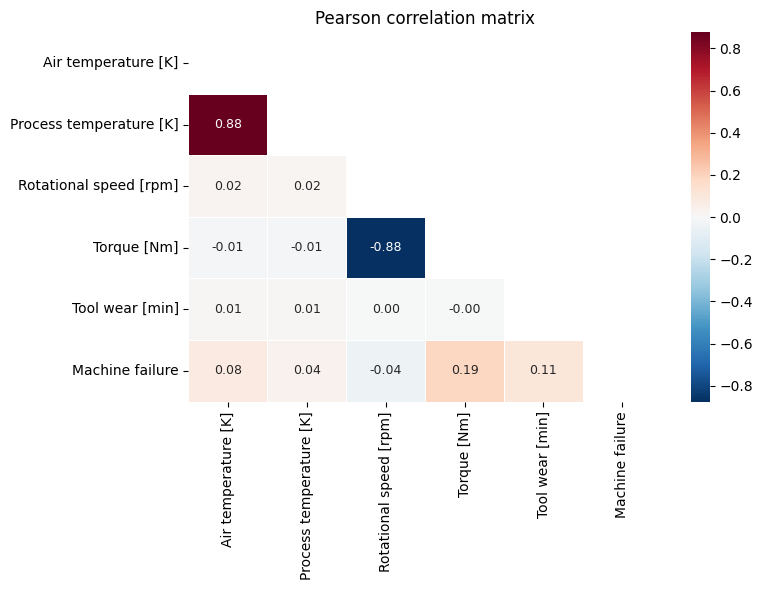

In [5]:
corr = df[sensor_cols + ["Machine failure"]].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, annot=True, fmt=".2f", mask=mask,
            cmap="RdBu_r", center=0,
            linewidths=0.5, ax=ax,
            annot_kws={"size": 9})

ax.set_title("Pearson correlation matrix")
plt.tight_layout()
plt.savefig("../outputs/correlation_heatmap.png", dpi=150)
plt.show()

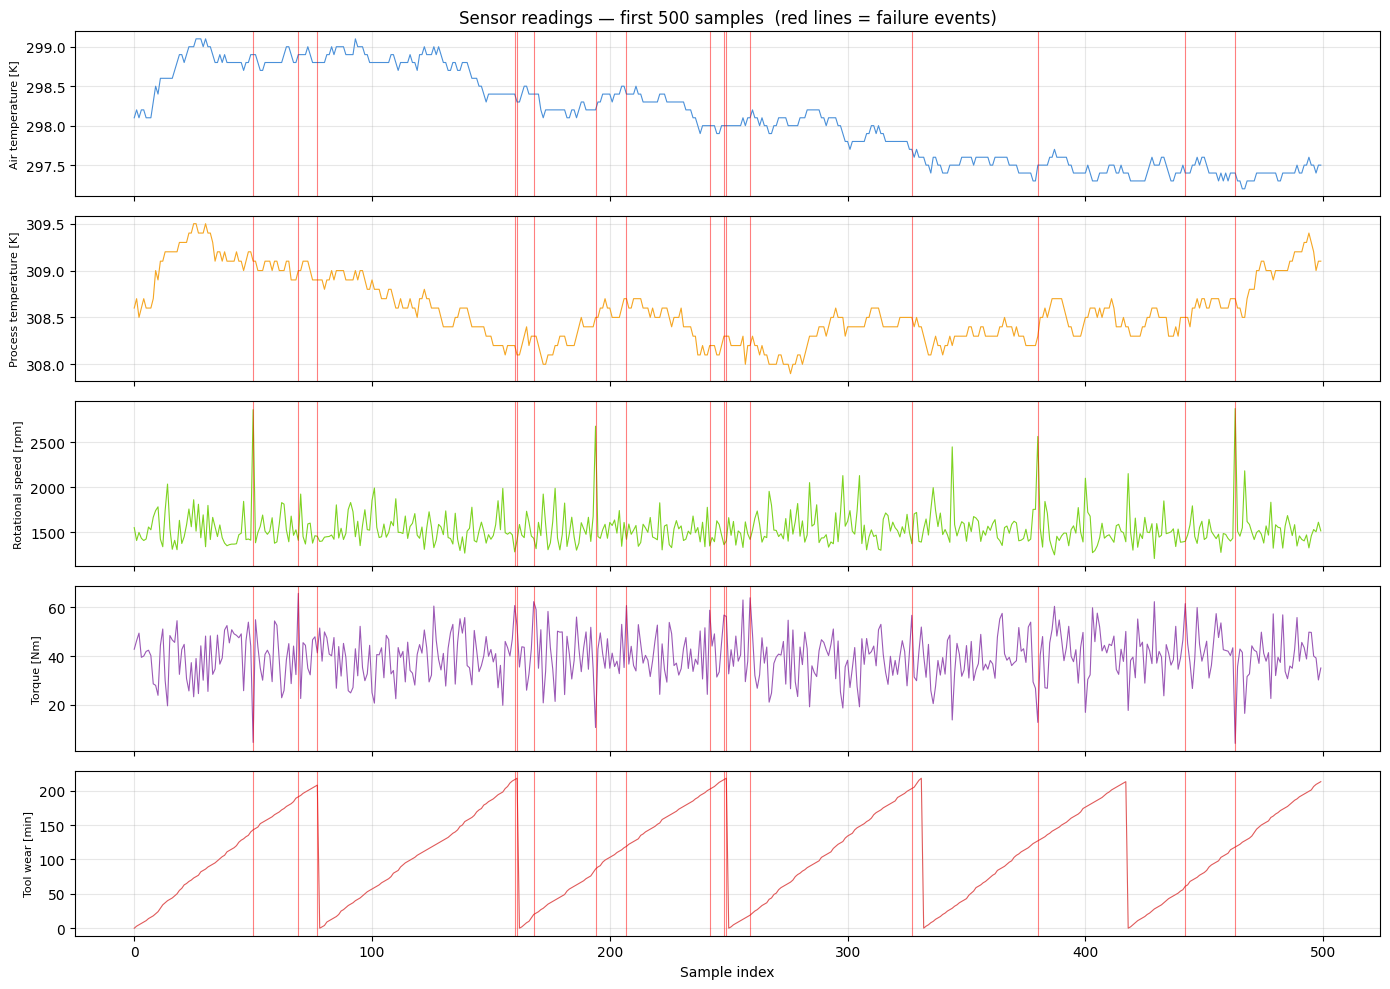

In [6]:
fig, axes = plt.subplots(5, 1, figsize=(14, 10), sharex=True)
colors = ["#4A90D9", "#F5A623", "#7ED321", "#9B59B6", "#E05A5A"]

for ax, col, color in zip(axes, sensor_cols, colors):
    ax.plot(df.index[:500], df[col].iloc[:500],
            color=color, linewidth=0.8)

    # Mark failure events as red vertical lines
    failures = df.index[:500][df["Machine failure"].iloc[:500] == 1]
    for f in failures:
        ax.axvline(f, color="red", alpha=0.5, linewidth=0.8)

    ax.set_ylabel(col, fontsize=8)
    ax.grid(True, alpha=0.3)

axes[0].set_title("Sensor readings — first 500 samples  (red lines = failure events)")
plt.xlabel("Sample index")
plt.tight_layout()
plt.savefig("../outputs/timeseries_overview.png", dpi=150)
plt.show()

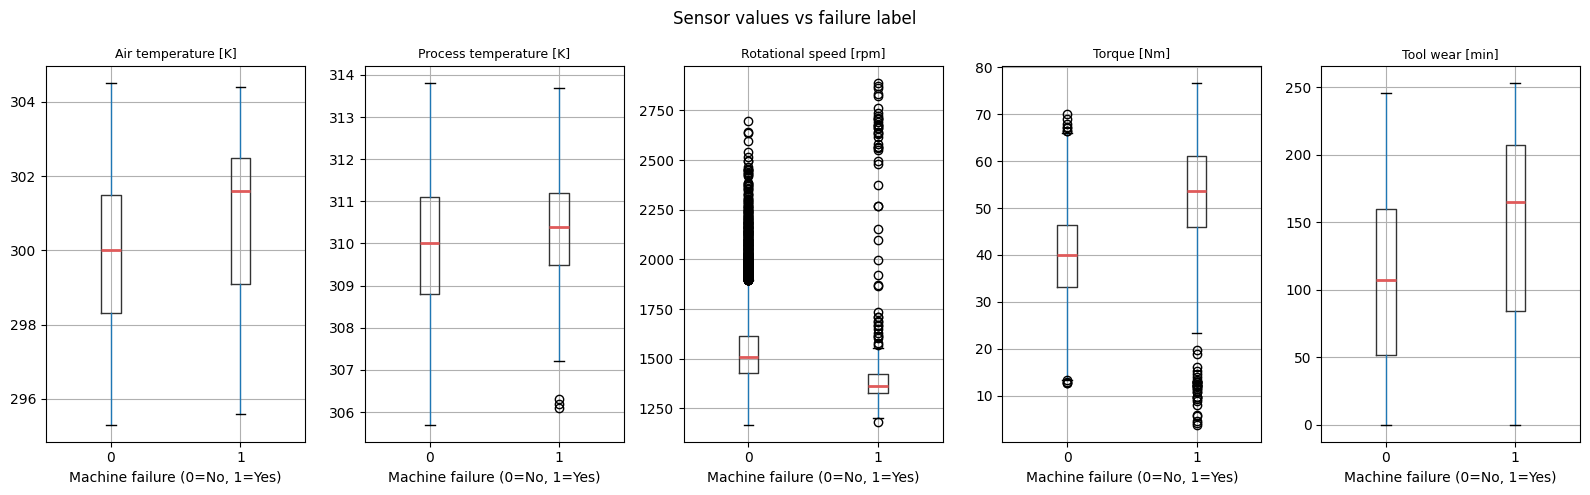

In [7]:
fig, axes = plt.subplots(1, 5, figsize=(16, 5))

for ax, col in zip(axes, sensor_cols):
    df.boxplot(column=col, by="Machine failure", ax=ax,
               boxprops=dict(color="#333"),
               medianprops=dict(color="#E05A5A", linewidth=2))
    ax.set_title(col, fontsize=9)
    ax.set_xlabel("Machine failure (0=No, 1=Yes)")

plt.suptitle("Sensor values vs failure label")
plt.tight_layout()
plt.savefig("../outputs/boxplots.png", dpi=150)
plt.show()

In [8]:


from scipy.stats import skew, kurtosis

stats_list = {}
for col in sensor_cols:
    stats_list[col] = {
        "mean":     df[col].mean(),
        "std":      df[col].std(),
        "min":      df[col].min(),
        "max":      df[col].max(),
        "skewness": skew(df[col]),
        "kurtosis": kurtosis(df[col])
    }

stats = pd.DataFrame(stats_list).T
print(stats.round(3))

stats.to_csv("../outputs/descriptive_stats.csv")
print("\nSaved to outputs/descriptive_stats.csv")

                             mean      std     min     max  skewness  kurtosis
Air temperature [K]       300.005    2.000   295.3   304.5     0.114    -0.836
Process temperature [K]   310.006    1.484   305.7   313.8     0.015    -0.500
Rotational speed [rpm]   1538.776  179.284  1168.0  2886.0     1.993     7.389
Torque [Nm]                39.987    9.969     3.8    76.6    -0.010    -0.014
Tool wear [min]           107.951   63.654     0.0   253.0     0.027    -1.167

Saved to outputs/descriptive_stats.csv
